# Rain-on-Snow SAR Demo — Arviat, Nunavut

This notebook detects **Rain-on-Snow (ROS)** events near Arviat and maps their footprint using free satellite radar data (Sentinel-1 SAR). No prior remote sensing experience needed.

---

### What is Rain-on-Snow?

Rain-on-Snow happens when liquid rain falls onto an existing snowpack — usually during a brief mid-winter warm spell. The rain soaks in and refreezes, forming a hard ice crust that:
- Blocks caribou from reaching buried forage
- Makes snowmachine travel unpredictable and dangerous
- Is invisible from the air — the surface looks like normal snow

### Why satellite radar?

Sentinel-1 is a radar satellite that sees through clouds and darkness. When liquid water infiltrates a snowpack, the dielectric constant rises from ~1.5 (dry snow) to ~3–5 (wet snow), causing the C-band VV backscatter to drop **3–10 dB** relative to a dry-snow reference (Ulaby et al. 1986, *Microwave Remote Sensing*; Nagler & Rott 2000, *IEEE TGRS*, 38(2):905–916). After refreezing, a smooth ice crust maintains a backscatter deficit of **2–4 dB** below baseline for weeks to months (Rott et al. 1992, *Ann. Glaciol.*, 17:280–284). We detect this signal fingerprint using **same-orbit ΔVV change detection** — the same-orbit constraint is mandatory to eliminate the 2–3 dB viewing-angle artefact that would otherwise swamp the ROS signal (Nagler & Rott 2000; Pivot 2012, *Remote Sens.*, 4(9):2827–2850).

### Notebook outline

| Section | What happens |
|---------|-------------|
| 1. Setup | Install packages, set configuration |
| 2. Weather | Download ERA5-Land data, plot temperature & precipitation |
| 3. ROS Detection | Flag candidate events with a 4-rule filter |
| 4. SAR Physics | How radar "sees" wet snow |
| 5. SAR Download | Fetch Sentinel-1 scenes from Planetary Computer |
| 6. ΔVV Maps | Compute change maps, display inline, save GeoTIFFs |
| 7. Results | Summary table, output files |


---
## 1. Setup

Run the cell below once to install all required packages. If they're already installed it will do nothing harmful.

In [1]:
# Install required packages (safe to re-run)
%pip install -q requests pandas numpy matplotlib rasterio pystac-client planetary-computer pyproj

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: C:\Users\as1612\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [2]:
import time, warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from datetime import datetime, timedelta
from pathlib import Path

%matplotlib inline
warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Output folders
for d in ['demo_arviat/data', 'demo_arviat/outputs', 'demo_arviat/figures']:
    Path(d).mkdir(parents=True, exist_ok=True)

print('✓ Packages loaded')

✓ Packages loaded


### Configuration

**This is the only cell you need to edit** to change the location, date range, or number of events.

In [3]:
# ── Edit this block to change location / dates ────────────────────────────────
ARVIAT_CONFIG = {
    "lat":        61.108,                        # latitude  (°N)
    "lon":        -94.058,                       # longitude (°W, enter as negative)
    "buffer_km":  50,                            # SAR chip half-width in km
    "date_range": ["2019-01-01", "2024-12-31"],  # ERA5 + SAR search window
    "max_events": 3,                             # number of ROS events to process
}
# ─────────────────────────────────────────────────────────────────────────────

# Physical detection threshold
# Sub-season SAR thresholds (Nagler & Rott 2000; Bartsch et al. 2010)
# Spring threshold is stricter — ambient melt already lowers VV,
# so -3 dB would produce false positives in March-May.
WET_SNOW_THRESHOLD = {
    'early_winter': -3.0,   # Oct-Nov: freeze-up, clean baseline
    'deep_winter':  -3.0,   # Dec-Feb: most stable SAR conditions
    'spring':       -5.0,   # Mar-May: stricter, ambient melt mimics ROS
}

def sub_season(month):
    if month in [10, 11]: return 'early_winter'
    if month in [12, 1, 2]: return 'deep_winter'
    return 'spring'
WINTER_MONTHS = [10, 11, 12, 1, 2, 3, 4, 5]  # Oct–May (snow season)

# Compute bounding box from lat/lon + buffer
# At 61°N: 1° lat ≈ 111 km; 1° lon ≈ 54 km
LAT, LON = ARVIAT_CONFIG['lat'], ARVIAT_CONFIG['lon']
BKM = ARVIAT_CONFIG['buffer_km']
dlat = BKM / 111.0
dlon = BKM / (111.0 * np.cos(np.radians(LAT)))
CHIP_BBOX = [LON - dlon, LAT - dlat, LON + dlon, LAT + dlat]  # [W, S, E, N]

print(f'Location : Arviat, Nunavut  ({LAT}°N, {abs(LON):.3f}°W)')
print(f'SAR bbox : W={CHIP_BBOX[0]:.3f}  S={CHIP_BBOX[1]:.3f}  E={CHIP_BBOX[2]:.3f}  N={CHIP_BBOX[3]:.3f}')
print(f'Period   : {ARVIAT_CONFIG["date_range"][0]} → {ARVIAT_CONFIG["date_range"][1]}')

Location : Arviat, Nunavut  (61.108°N, 94.058°W)
SAR bbox : W=-94.990  S=60.658  E=-93.126  N=61.558
Period   : 2019-01-01 → 2024-12-31


contextily not found — install with:  pip install contextily
Falling back to plain axes with coastline approximation.


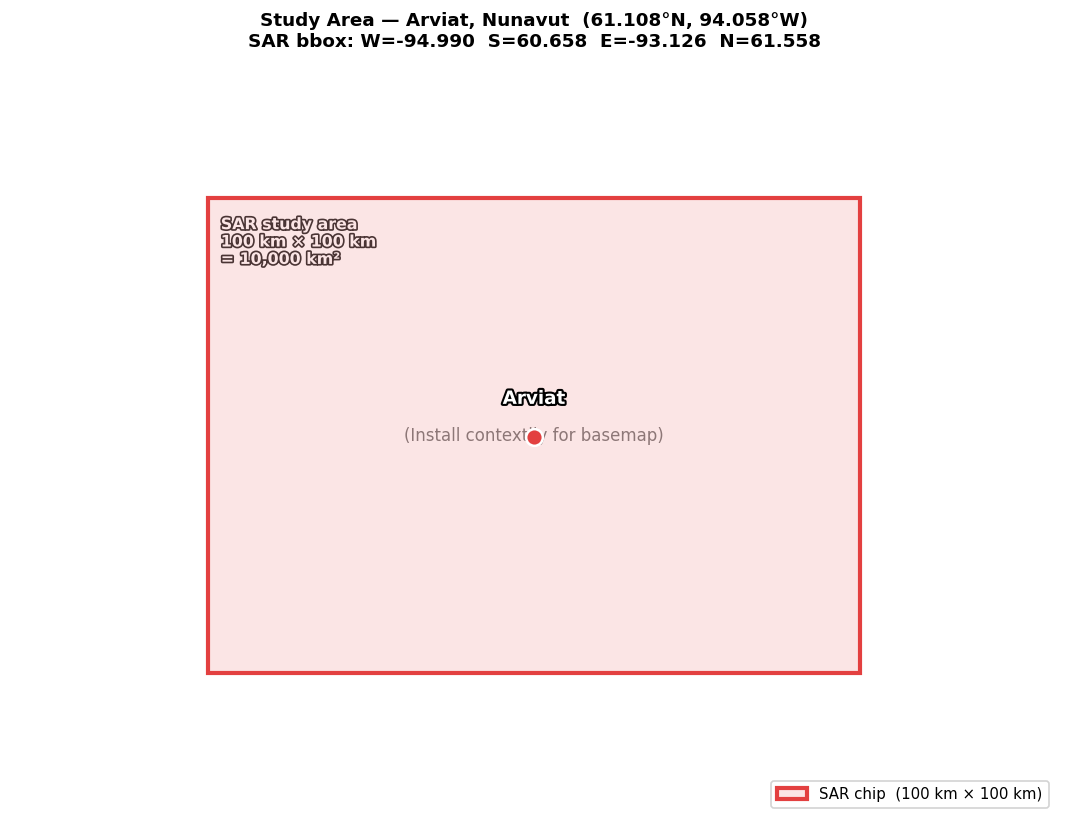


Study area: 100 km × 100 km = 10,000 km²
Sentinel-1 pixels at 10 m: ~5,000 × 5,000 = 25,000,000 pixels per chip


In [4]:
# ── Study area map ─────────────────────────────────────────────────────────────
# Shows the SAR bounding box overlaid on a real basemap.
# pip install contextily  (if not already installed)
try:
    import contextily as ctx
    HAS_CTX = True
except ImportError:
    HAS_CTX = False
    print("contextily not found — install with:  pip install contextily")
    print("Falling back to plain axes with coastline approximation.")

from pyproj import Transformer
import matplotlib.patches as patches
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(9, 7))

# ── Convert bbox corners to Web Mercator for contextily ───────────────────────
tf = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
west_m,  south_m = tf.transform(CHIP_BBOX[0], CHIP_BBOX[1])
east_m,  north_m = tf.transform(CHIP_BBOX[2], CHIP_BBOX[3])
cx_m,    cy_m    = tf.transform(LON, LAT)

# Add 30% padding around the bbox for context
pad_x = (east_m  - west_m)  * 0.30
pad_y = (north_m - south_m) * 0.30
ax.set_xlim(west_m  - pad_x, east_m  + pad_x)
ax.set_ylim(south_m - pad_y, north_m + pad_y)

if HAS_CTX:
    ctx.add_basemap(ax, source=ctx.providers.Esri.WorldTerrain,
                    zoom="auto", attribution_size=6)
else:
    ax.set_facecolor("#cce5ff")
    ax.text(0.5, 0.5, "(Install contextily for basemap)", transform=ax.transAxes,
            ha="center", va="center", fontsize=10, color="gray")

# ── SAR bounding box rectangle ────────────────────────────────────────────────
bbox_w = east_m  - west_m
bbox_h = north_m - south_m
rect = patches.FancyBboxPatch(
    (west_m, south_m), bbox_w, bbox_h,
    boxstyle="square,pad=0",
    linewidth=2.5, edgecolor="#e34040", facecolor="#e3404022",
    zorder=4, label=f"SAR chip  ({BKM*2:.0f} km × {BKM*2:.0f} km)"
)
ax.add_patch(rect)

# ── Arviat marker ─────────────────────────────────────────────────────────────
ax.plot(cx_m, cy_m, "o", ms=10, color="#e34040", zorder=6,
        markeredgecolor="white", markeredgewidth=1.5)
ax.text(cx_m, cy_m + bbox_h * 0.07, "Arviat", fontsize=11, fontweight="bold",
        ha="center", color="white", zorder=7,
        path_effects=[pe.withStroke(linewidth=2.5, foreground="black")])

# ── Area annotation ───────────────────────────────────────────────────────────
area_km2 = (BKM * 2) ** 2
ax.annotate(
    f"SAR study area\n{BKM*2:.0f} km × {BKM*2:.0f} km\n= {area_km2:,.0f} km²",
    xy=(west_m + bbox_w * 0.02, north_m - bbox_h * 0.04),
    fontsize=9.5, color="white", fontweight="bold", va="top",
    path_effects=[pe.withStroke(linewidth=2, foreground="#333")]
)

ax.set_title(
    f"Study Area — Arviat, Nunavut  ({LAT}°N, {abs(LON):.3f}°W)\n"
    f"SAR bbox: W={CHIP_BBOX[0]:.3f}  S={CHIP_BBOX[1]:.3f}  "
    f"E={CHIP_BBOX[2]:.3f}  N={CHIP_BBOX[3]:.3f}",
    fontsize=11, fontweight="bold"
)
ax.legend(loc="lower right", fontsize=9, framealpha=0.85)
ax.axis("off")

plt.tight_layout()
plt.show()
print(f"\nStudy area: {BKM*2} km × {BKM*2} km = {area_km2:,.0f} km²")
print(f"Sentinel-1 pixels at 10 m: ~{int(BKM*100):,} × {int(BKM*100):,} = "
      f"{int(BKM*100)**2:,} pixels per chip")

---
## 2. Weather Data

We download daily ERA5-Land reanalysis data from [Open-Meteo](https://open-meteo.com) — a free public API that requires no account or API key. ERA5-Land is a global climate dataset produced by ECMWF from 1950 to present at ~9 km resolution.

Variables we need:
- `tmax_c` — maximum daily air temperature (°C)
- `prcp_mm` — total daily precipitation (mm)
- `rain_mm` — rainfall fraction (mm)
- `snow_mm` — snowfall water equivalent (mm)

In [5]:
def fetch_era5_weather(lat, lon, start_date, end_date, cache_path=None):
    """Download ERA5-Land daily data via Open-Meteo. Caches result to CSV.
    snow_depth is only available hourly — fetched separately and aggregated to daily max.
    """
    if cache_path and Path(cache_path).exists():
        print(f'Using cached ERA5 data: {cache_path}')
        df_cached = pd.read_csv(cache_path, parse_dates=['date'])
        if 'snow_depth_m' in df_cached.columns:
            return df_cached
        print('  Cache missing snow_depth_m — re-downloading.')

    print(f'Downloading ERA5-Land for ({lat:.3f}°N, {abs(lon):.3f}°W) …')
    base = 'https://archive-api.open-meteo.com/v1/archive'
    common = dict(latitude=lat, longitude=lon,
                  start_date=start_date, end_date=end_date,
                  timezone='UTC', models='era5_land')

    def _get(params, label):
        for attempt in range(3):
            try:
                r = requests.get(base, params=params, timeout=90)
                r.raise_for_status()
                return r.json()
            except Exception as e:
                if attempt == 2: raise RuntimeError(f'ERA5 {label} download failed: {e}')
                print(f'  Retry {attempt+1}/3…'); time.sleep(5)

    # ── daily variables ───────────────────────────────────────────────────────
    daily_json = _get({**common,
        'daily': 'temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,snowfall_sum'
    }, 'daily')
    df = pd.DataFrame(daily_json['daily'])
    df['date'] = pd.to_datetime(df['time'])
    df = df.drop(columns=['time']).rename(columns={
        'temperature_2m_max': 'tmax_c', 'temperature_2m_min': 'tmin_c',
        'precipitation_sum': 'prcp_mm', 'rain_sum': 'rain_mm', 'snowfall_sum': 'snow_mm',
    })

    # ── hourly snow_depth → daily max ─────────────────────────────────────────
    hourly_json = _get({**common, 'hourly': 'snow_depth'}, 'hourly snow_depth')
    dh = pd.DataFrame(hourly_json['hourly'])
    dh['date'] = pd.to_datetime(dh['time']).dt.normalize()
    snow_daily = dh.groupby('date')['snow_depth'].max().reset_index()
    snow_daily = snow_daily.rename(columns={'snow_depth': 'snow_depth_m'})
    df = df.merge(snow_daily, on='date', how='left')

    # Fill missing precip values with 0 (API returns NaN for trace/no-data days)
    for col in ['prcp_mm', 'rain_mm', 'snow_mm', 'snow_depth_m']:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    if cache_path:
        df.to_csv(cache_path, index=False)
        print(f'Saved to {cache_path}')
    return df

In [6]:
wx = fetch_era5_weather(
    ARVIAT_CONFIG['lat'], ARVIAT_CONFIG['lon'],
    ARVIAT_CONFIG['date_range'][0], ARVIAT_CONFIG['date_range'][1],
    cache_path='demo_arviat/data/era5_arviat.csv'
)
print(f'{len(wx):,} daily records  ({wx.date.min().date()} → {wx.date.max().date()})')
wx.head()

Using cached ERA5 data: demo_arviat/data/era5_arviat.csv
2,192 daily records  (2019-01-01 → 2024-12-31)


,tmax_c,tmin_c,prcp_mm,rain_mm,snow_mm,date,snow_depth_m
0,-26.9,-30.9,0,0,0,2019-01-01,0.45
1,-22.8,-27.8,0,0,0,2019-01-02,0.46
2,-18.1,-22.8,0,0,0,2019-01-03,0.47
3,-19.2,-26.9,0,0,0,2019-01-04,0.48
4,-26.1,-28.4,0,0,0,2019-01-05,0.48


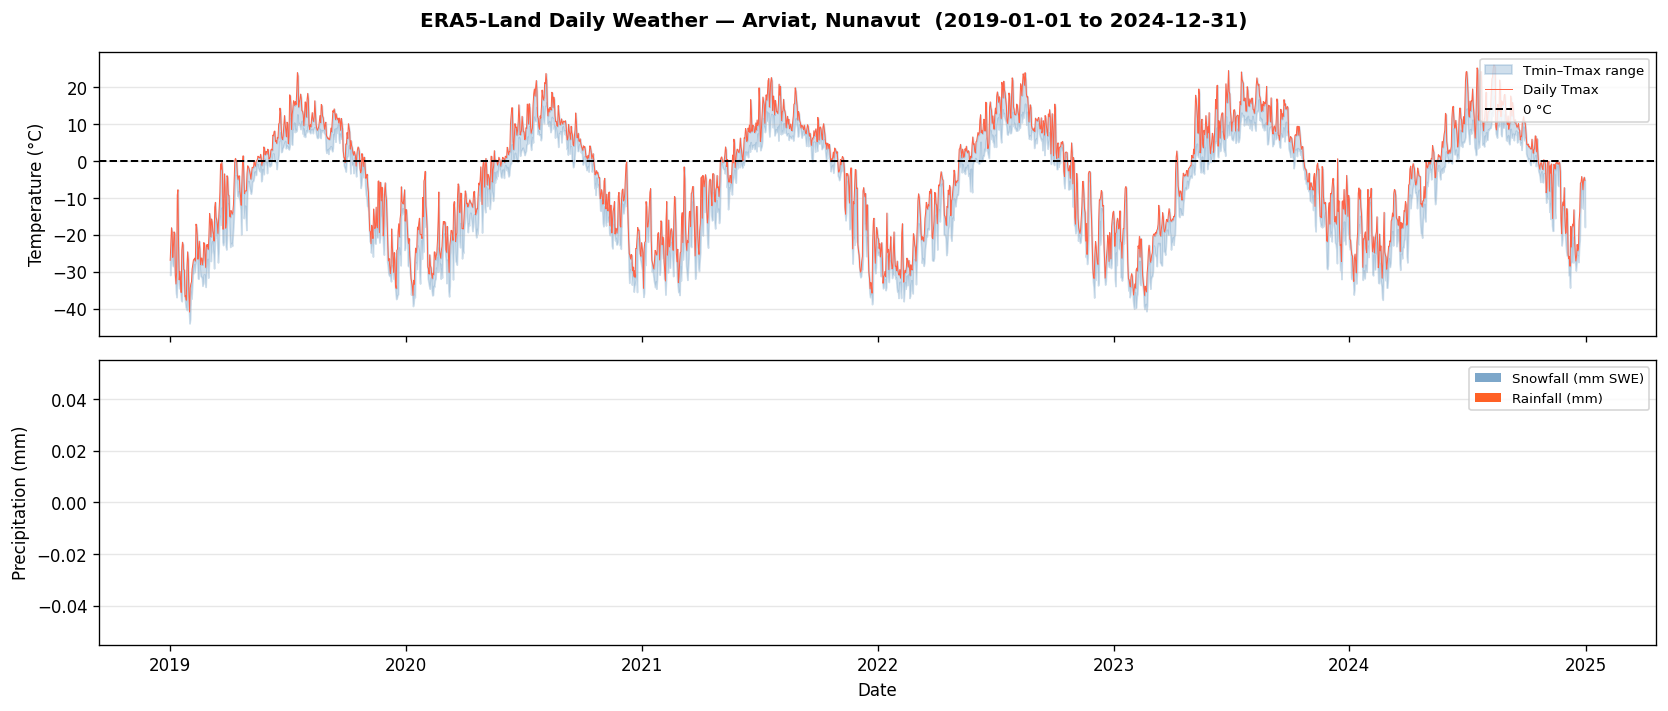

In [7]:
# ── Weather overview plot ─────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle(f'ERA5-Land Daily Weather — Arviat, Nunavut  '
             f'({ARVIAT_CONFIG["date_range"][0]} to {ARVIAT_CONFIG["date_range"][1]})',
             fontsize=12, fontweight='bold')

# Temperature
ax1.fill_between(wx.date, wx.tmin_c, wx.tmax_c, alpha=0.25, color='steelblue', label='Tmin–Tmax range')
ax1.plot(wx.date, wx.tmax_c, lw=0.6, color='tomato', label='Daily Tmax')
ax1.axhline(0, color='black', lw=1.2, ls='--', label='0 °C')
ax1.set_ylabel('Temperature (°C)')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(axis='y', alpha=0.3)

# Precipitation — split rain vs snow
ax2.bar(wx.date, wx.snow_mm, color='steelblue', width=1, alpha=0.7, label='Snowfall (mm SWE)')
ax2.bar(wx.date, wx.rain_mm, color='orangered', width=1, alpha=0.85, label='Rainfall (mm)')
ax2.set_ylabel('Precipitation (mm)')
ax2.set_xlabel('Date')
ax2.legend(fontsize=8)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---
## 3. Rain-on-Snow Detection

We flag a day as a ROS event when **all five rules are true simultaneously**,
following Rennert et al. (2009, *J. Climate*) and Peeters et al. (2019, *Climatic Change*):

| Rule | Condition | Why |
|------|-----------|-----|
| 1 | `snow_depth_m ≥ 0.01 m` | Actual ERA5 snowpack depth — eliminates rain on bare ground without relying on a rolling proxy |
| 2 | `rain_mm ≥ 1.0 mm` | Minimum liquid threshold (Rennert et al. 2009) — trace amounts freeze before reaching snowpack |
| 3 | `rain_mm / prcp_mm ≥ 0.5` | Majority of precip must be liquid — filters mixed-phase events where snow dominates |
| 4 | `tmax_c > 0 °C` | Above-freezing air temperature |
| 5 | Month ∈ Oct–May | Snow-season guard |

Events are ranked by **rain amount** (not total precip) and the top `max_events` are selected.

In [8]:
def detect_ros_events(df, max_events=3):
    '''
    Improved ROS filter — Rennert et al. (2009, J. Climate) and
    Peeters et al. (2019, Climatic Change). Five rules must all be true:

    Rule 1: snow_depth_m >= 0.01 m   (actual ERA5 snowpack — not a rolling proxy)
    Rule 2: rain_mm >= 1.0           (Rennert et al. minimum liquid threshold)
    Rule 3: rain_mm / prcp_mm >= 0.5 (majority of precip must be liquid)
    Rule 4: tmax_c > 0 C             (above-freezing air temperature)
    Rule 5: month in Oct-May         (snow-season guard)
    '''
    SNOW_DEPTH_MIN_M = 0.01   # metres
    RAIN_MIN_MM      = 1.0    # mm
    RAIN_FRAC_MIN    = 0.5    # fraction (0-1)

    df = df.copy()
    df['month'] = df['date'].dt.month
    rain_frac = df['rain_mm'] / df['prcp_mm'].clip(lower=0.001)

    mask = (
        df['month'].isin(WINTER_MONTHS)          &
        (df['snow_depth_m'] >= SNOW_DEPTH_MIN_M) &
        (df['rain_mm']  >= RAIN_MIN_MM)          &
        (rain_frac      >= RAIN_FRAC_MIN)        &
        (df['tmax_c']   > 0)
    )
    events = df[mask].copy().sort_values('rain_mm', ascending=False)
    print(f'{len(events)} candidate ROS events found in the full period')
    events = events.head(max_events).sort_values('date')
    events['sub_season'] = events['month'].apply(sub_season)
    print(f'Top {len(events)} selected (highest liquid precip):')
    for _, r in events.iterrows():
        thresh = WET_SNOW_THRESHOLD[r['sub_season']]
        print(f"  {r['date'].date()}  [{r['sub_season']}]  "
              f"rain={r['rain_mm']:.1f} mm  tmax={r['tmax_c']:.1f} C  "
              f"snow_depth={r['snow_depth_m']:.2f} m  threshold={thresh} dB")
    return events

In [9]:
ros_events = detect_ros_events(wx, max_events=ARVIAT_CONFIG['max_events'])

0 candidate ROS events found in the full period
Top 0 selected (highest liquid precip):


In [10]:
# Display event table
display_cols = ['date', 'sub_season', 'tmax_c', 'rain_mm', 'prcp_mm', 'snow_depth_m']
ros_events[display_cols].rename(columns={
    'date': 'Event date', 'sub_season': 'Sub-season', 'tmax_c': 'Tmax (°C)',
    'rain_mm': 'Rain (mm)', 'prcp_mm': 'Total precip (mm)',
    'snow_depth_m': 'Snow depth (m)',
}).round(2)

,Event date,Sub-season,Tmax (°C),Rain (mm),Total precip (mm),Snow depth (m)


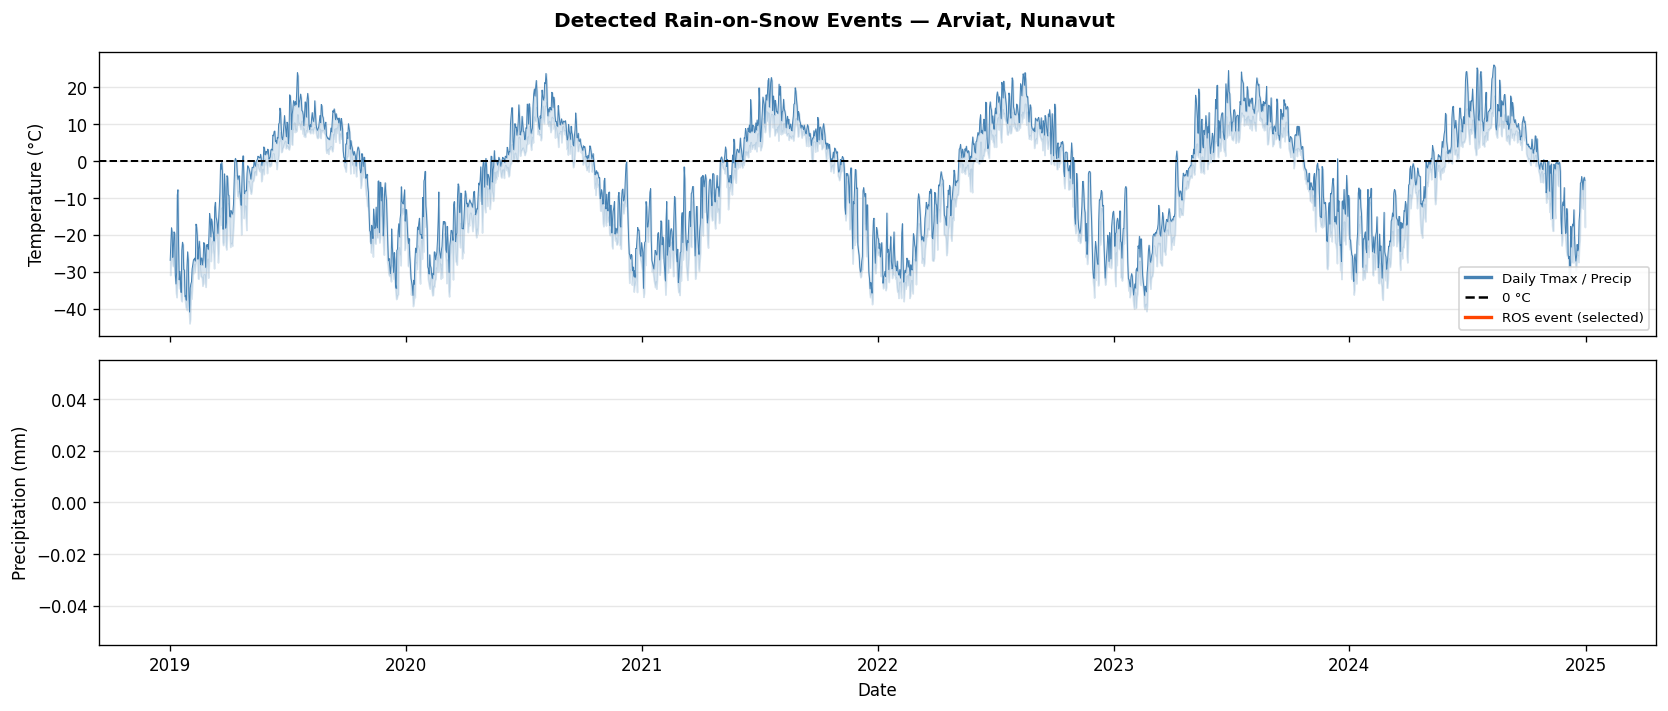

In [11]:
# ── Highlight ROS events on the weather plot ─────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
fig.suptitle('Detected Rain-on-Snow Events — Arviat, Nunavut', fontsize=12, fontweight='bold')

ax1.fill_between(wx.date, wx.tmin_c, wx.tmax_c, alpha=0.2, color='steelblue')
ax1.plot(wx.date, wx.tmax_c, lw=0.6, color='steelblue', label='Daily Tmax')
ax1.axhline(0, color='black', lw=1.2, ls='--', label='0 °C')
ax1.set_ylabel('Temperature (°C)')
ax1.grid(axis='y', alpha=0.3)

ax2.bar(wx.date, wx.prcp_mm, color='steelblue', width=1, alpha=0.6, label='Total precip (mm)')
ax2.set_ylabel('Precipitation (mm)')
ax2.set_xlabel('Date')
ax2.grid(axis='y', alpha=0.3)

# Overlay ROS event markers
for _, row in ros_events.iterrows():
    for ax in (ax1, ax2):
        ax.axvline(row['date'], color='orangered', lw=2, alpha=0.85, zorder=5)
    ax1.annotate(
        f"ROS\n{row['date'].strftime('%b %d')}",
        xy=(row['date'], ax1.get_ylim()[1] * 0.85),
        fontsize=7.5, color='orangered', ha='center', fontweight='bold'
    )

from matplotlib.lines import Line2D
legend_els = [
    Line2D([0], [0], color='steelblue', lw=2, label='Daily Tmax / Precip'),
    Line2D([0], [0], color='black',     lw=1.5, ls='--', label='0 °C'),
    Line2D([0], [0], color='orangered', lw=2, label='ROS event (selected)'),
]
ax1.legend(handles=legend_els, fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

---
## 4. SAR Physics — How Radar "Sees" Wet Snow

The diagram below shows what happens to the Sentinel-1 radar signal before and after a Rain-on-Snow event.

```
BEFORE (dry snow)                  AFTER (wet snow / ice crust)
──────────────────                 ─────────────────────────────
Radar pulses → scatters            Radar pulses → absorbed by
throughout dry snowpack            liquid water in snowpack
(high volume scatter)              (much less backscatter)

VV backscatter: ~−12 dB            VV backscatter: ~−18 dB
                                   ΔVV = −6 dB  ← signal we detect
```

**ΔVV = post-event VV − dry-snow baseline VV**

- **ΔVV < −3 dB** → probable wet snow or ROS signal  
- **ΔVV ≈ 0 dB** → no change, normal dry snow  
- **ΔVV > 0 dB** → rougher surface (e.g., wind-packed crust)

### Why same-orbit matters

Sentinel-1 makes passes on **ascending** (south→north, evening) and **descending** (north→south, morning) orbits, looking at the ground from slightly different angles. Mixing orbits introduces a spurious **2–3 dB artefact** — larger than the ROS signal itself.

> **Rule:** Every post-event scene must be paired with a baseline from the **exact same orbit direction**.

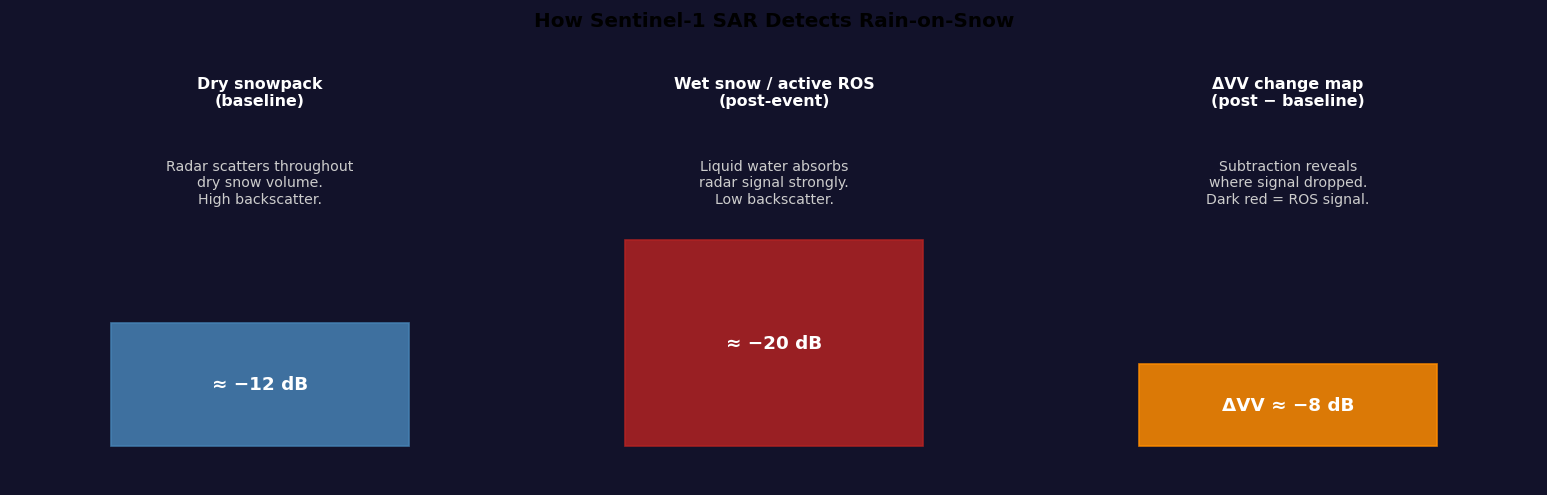

In [12]:
# ── Visual schematic of the ROS radar signal ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('How Sentinel-1 SAR Detects Rain-on-Snow', fontsize=12, fontweight='bold', y=1.02)

panel_info = [
    ('Dry snowpack\n(baseline)',
     'steelblue', -12,
     'Radar scatters throughout\ndry snow volume.\nHigh backscatter.',
     '≈ −12 dB'),
    ('Wet snow / active ROS\n(post-event)',
     'firebrick', -20,
     'Liquid water absorbs\nradar signal strongly.\nLow backscatter.',
     '≈ −20 dB'),
    ('ΔVV change map\n(post − baseline)',
     'darkorange', -8,
     'Subtraction reveals\nwhere signal dropped.\nDark red = ROS signal.',
     'ΔVV ≈ −8 dB'),
]

for ax, (title, color, val, desc, label) in zip(axes, panel_info):
    ax.set_facecolor('#1a1a2e')
    # Draw a simple backscatter bar
    bar_h = abs(val) / 25
    rect = plt.Rectangle((0.2, 0.1), 0.6, bar_h * 0.7, color=color, alpha=0.85)
    ax.add_patch(rect)
    ax.text(0.5, 0.1 + bar_h * 0.35, label, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white')
    ax.text(0.5, 0.88, desc, ha='center', va='top', fontsize=8.5,
            color='#cccccc', wrap=True, multialignment='center')
    ax.set_title(title, fontsize=9.5, fontweight='bold', color='white', pad=6)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_facecolor('#1a1a2e')
    for spine in ax.spines.values():
        spine.set_edgecolor('#444')

fig.patch.set_facecolor('#12122a')
plt.tight_layout()
plt.show()

---
## 5. Download Sentinel-1 SAR

Sentinel-1 data is publicly available via [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com) — no account required. We use the `pystac-client` library to search the STAC catalog and `rasterio` to stream only the pixels inside our bounding box (much faster than downloading full scenes).

For each ROS event we need **two scenes from the same orbit**:
1. **Post-event** — acquired 0–15 days after the event  
2. **Baseline** — acquired 14–90 days before the event (dry-snow conditions)

In [13]:
def s1_search(bbox, date_str, orbit=None, days_before=2, days_after=15, max_items=8):
    """
    Search Planetary Computer for Sentinel-1 RTC scenes.
    bbox      : [W, S, E, N] in WGS84
    date_str  : 'YYYY-MM-DD' (start of search window)
    orbit     : 'ascending' or 'descending' (None = either)
    """
    import pystac_client
    import planetary_computer as pc

    catalog = pystac_client.Client.open(
        'https://planetarycomputer.microsoft.com/api/stac/v1',
        modifier=pc.sign_inplace,
    )
    dt = datetime.strptime(date_str, '%Y-%m-%d')
    t0 = (dt - timedelta(days=days_before)).strftime('%Y-%m-%d')
    t1 = (dt + timedelta(days=days_after)).strftime('%Y-%m-%d')
    query = {'sar:orbit_state': {'in': [orbit]}} if orbit else {}
    try:
        return list(catalog.search(
            collections=['sentinel-1-rtc'], bbox=bbox,
            datetime=f'{t0}/{t1}', query=query, max_items=max_items
        ).items())
    except Exception as e:
        print(f'  STAC search error: {e}'); return []


def load_vv(item, bbox_wgs84):
    """
    Stream VV backscatter chip (dB) for the bbox area only — fast windowed read.
    Returns (vv_db_array, affine_transform, crs, orbit_str) or None.
    """
    import rasterio
    from rasterio.windows import from_bounds as win_from_bounds
    from pyproj import Transformer

    asset = item.assets.get('vv')
    if asset is None: return None
    orbit = item.properties.get('sar:orbit_state', 'unknown')
    try:
        with rasterio.open(asset.href) as src:
            tf = Transformer.from_crs('EPSG:4326', src.crs, always_xy=True)
            w, s = tf.transform(bbox_wgs84[0], bbox_wgs84[1])
            e, n = tf.transform(bbox_wgs84[2], bbox_wgs84[3])
            win  = win_from_bounds(w, s, e, n, src.transform)
            data = src.read(1, window=win).astype(np.float32)
            transform, crs = src.window_transform(win), src.crs
        data[data <= 0] = np.nan
        vv_db = 10.0 * np.log10(data)          # linear amplitude → dB
        vv_db[~np.isfinite(vv_db)] = np.nan
        return vv_db, transform, crs, orbit
    except Exception as e:
        print(f'  VV load error: {e}'); return None


def find_baseline(bbox, event_date_str, orbit, search_days=90):
    """
    Find the dry-snow baseline scene: same orbit, 14–90 days before the event.
    Returns the STAC item closest to 45 days before the event, or None.
    """
    dt    = datetime.strptime(event_date_str, '%Y-%m-%d')
    start = (dt - timedelta(days=search_days)).strftime('%Y-%m-%d')
    span  = (dt - timedelta(days=14) - datetime.strptime(start, '%Y-%m-%d')).days
    items = s1_search(bbox, start, orbit=orbit, days_before=0, days_after=span, max_items=12)
    if not items: return None
    target = dt - timedelta(days=45)
    items.sort(key=lambda i: abs(
        (datetime.fromisoformat(i.properties['datetime'][:10]) - target).days
    ))
    return items[0]


def save_geotiff(path, array, transform, crs):
    """Write a single-band float32 GeoTIFF (deflate compressed)."""
    import rasterio
    with rasterio.open(str(path), 'w', driver='GTiff',
                       height=array.shape[0], width=array.shape[1],
                       count=1, dtype='float32', crs=crs,
                       transform=transform, compress='deflate') as dst:
        dst.write(array.astype('float32'), 1)

print('✓ SAR helper functions defined')

✓ SAR helper functions defined


---
## 6. ΔVV Change Detection

For each detected ROS event we:
1. Find and download a **post-event** Sentinel-1 scene
2. Find and download a **same-orbit baseline** scene
3. Compute `ΔVV = post_VV − baseline_VV`
4. Display a 3-panel map inline
5. Save three GeoTIFFs (baseline / post-event / delta) to `demo_arviat/outputs/`

**Reading the ΔVV map:**
- **Dark red** (ΔVV < −3 dB) → radar signal dropped → probable wet snow / ROS
- **White / pale** (ΔVV ≈ 0 dB) → no change
- **Blue** (ΔVV > 0 dB) → signal increased (e.g. rougher wind-packed surface)

> ⏳ Each event takes 2–5 minutes to download. The SAR data is streamed only for the bounding box, not the full scene.

In [14]:
def process_and_plot_event(event_row, bbox, out_dir='demo_arviat/outputs', fig_dir='demo_arviat/figures'):
    """
    Full pipeline for one ROS event: SAR search → load → align → ΔVV → plot inline → save GeoTIFFs.
    Returns a metadata dict or None if SAR data is unavailable.
    """
    out_dir = Path(out_dir)
    fig_dir = Path(fig_dir)
    event_date = event_row['date'].strftime('%Y-%m-%d')
    tag      = event_date.replace('-', '')
    season   = event_row.get('sub_season', 'deep_winter')
    threshold = WET_SNOW_THRESHOLD[season]
    SEP = '─' * 55
    print(f'\n{SEP}')
    print(f'Event: {event_date}  |  prcp={event_row["prcp_mm"]:.1f} mm  tmax={event_row["tmax_c"]:.1f}°C')
    print(SEP)

    # ── 1. Post-event scene ──────────────────────────────────────────────────
    print('  Searching for post-event SAR scene (0–15 days after event)…')
    post_items = s1_search(bbox, event_date, orbit=None, days_before=0, days_after=15)
    if not post_items:
        print('  ✗ No post-event scene found — skipping.')
        return None

    post_result = None
    for item in post_items:
        post_result = load_vv(item, bbox)
        if post_result:
            post_date  = item.properties['datetime'][:10]
            post_orbit = post_result[3]
            break
    if not post_result:
        print('  ✗ Could not read post-event VV — skipping.')
        return None
    post_vv, post_transform, post_crs, _ = post_result
    print(f'  ✓ Post-event  : {post_date}  ({post_orbit} orbit)')

    # ── 2. Same-orbit baseline ───────────────────────────────────────────────
    print(f'  Searching for same-orbit ({post_orbit}) baseline 14–90 days before…')
    baseline_item = find_baseline(bbox, event_date, orbit=post_orbit, search_days=90)
    if not baseline_item:
        print('  ✗ No same-orbit baseline found — skipping.')
        return None
    baseline_result = load_vv(baseline_item, bbox)
    if not baseline_result:
        print('  ✗ Could not read baseline VV — skipping.')
        return None
    baseline_vv, _, _, _ = baseline_result
    baseline_date = baseline_item.properties['datetime'][:10]
    print(f'  ✓ Baseline    : {baseline_date}  ({post_orbit} orbit, dry snow)')

    # ── 3. Align + compute ΔVV ───────────────────────────────────────────────
    r = min(post_vv.shape[0], baseline_vv.shape[0])
    c = min(post_vv.shape[1], baseline_vv.shape[1])
    post_vv, baseline_vv = post_vv[:r, :c], baseline_vv[:r, :c]
    delta_vv = post_vv - baseline_vv

    wet_pct    = float(np.nanmean(delta_vv < threshold) * 100)
    mean_delta = float(np.nanmean(delta_vv))
    ros_detected = wet_pct > 20
    print(f'  Mean ΔVV = {mean_delta:+.2f} dB  |  '
          f'Pixels below {threshold} dB [{season}]: {wet_pct:.1f}%  |  '
          f'ROS signal: {"YES ✓" if ros_detected else "NO ✗"}')

    # ── 4. Inline figure ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
    fig.suptitle(
        f'Rain-on-Snow Event: {event_date} | Arviat, Nunavut\n'
        f'Baseline: {baseline_date}   →   Post-event: {post_date}   '
        f'({post_orbit} orbit, Sentinel-1 RTC VV)',
        fontsize=10, fontweight='bold', y=1.02
    )

    # Panel 1: Baseline (gray)
    im0 = axes[0].imshow(baseline_vv, cmap='gray', vmin=-25, vmax=0, origin='upper')
    axes[0].set_title(f'① Baseline VV (dB)\n{baseline_date}\nDry snow — reference image', fontsize=9)
    axes[0].axis('off')
    cb0 = plt.colorbar(im0, ax=axes[0], shrink=0.78, pad=0.02)
    cb0.set_label('VV backscatter (dB)', fontsize=8)

    # Panel 2: Post-event (gray)
    im1 = axes[1].imshow(post_vv, cmap='gray', vmin=-25, vmax=0, origin='upper')
    axes[1].set_title(f'② Post-Event VV (dB)\n{post_date}\nAfter rain-on-snow event', fontsize=9)
    axes[1].axis('off')
    cb1 = plt.colorbar(im1, ax=axes[1], shrink=0.78, pad=0.02)
    cb1.set_label('VV backscatter (dB)', fontsize=8)

    # Panel 3: ΔVV — red = signal dropped = wet snow signal
    # RdBu_r: negative values → red (signal dropped = wet snow)
    #          positive values → blue (signal increased)
    im2 = axes[2].imshow(delta_vv, cmap='RdBu_r', vmin=-8, vmax=8, origin='upper')
    try:
        axes[2].contour(
            delta_vv < threshold,
            levels=[0.5], colors='black', linewidths=0.8, alpha=0.7
        )
    except Exception:
        pass
    axes[2].set_title(
        f'③ ΔVV = Post − Baseline (dB)\n'
        f'[{season}]  threshold={threshold} dB  wet-snow: {wet_pct:.1f}%',
        fontsize=9
    )
    axes[2].axis('off')
    cb2 = plt.colorbar(im2, ax=axes[2], shrink=0.78, pad=0.02)
    cb2.set_label('ΔVV (dB)', fontsize=8)
    cb2.ax.axhline(threshold, color='black', lw=1.5, ls='--')
    cb2.ax.text(2.2, threshold, f'{threshold} dB', fontsize=7, va='center')

    # Colour legend strip at bottom
    red_p  = mpatches.Patch(color='#e34040', label='Signal dropped (wet snow / ROS)')
    white_p = mpatches.Patch(color='#efefef', label='No change (dry snow)',
                              edgecolor='gray', linewidth=0.5)
    blue_p = mpatches.Patch(color='#4070d0', label='Signal increased (rougher surface)')
    fig.legend(handles=[red_p, white_p, blue_p], loc='lower center',
               ncol=3, fontsize=8.5, framealpha=0.9,
               bbox_to_anchor=(0.5, -0.04))

    plt.tight_layout()
    fig_path = fig_dir / f'ros_event_{tag}.png'
    fig.savefig(str(fig_path), dpi=150, bbox_inches='tight')
    plt.show()     # display inline in notebook
    plt.close(fig)
    print(f'  Figure saved: {fig_path.name}')

    # ── 5. Save GeoTIFFs ─────────────────────────────────────────────────────
    tif_base = out_dir / f'baseline_{baseline_date.replace("-","")}.tif'
    tif_post = out_dir / f'post_event_{tag}.tif'
    tif_dv   = out_dir / f'delta_vv_{tag}.tif'
    save_geotiff(tif_base, baseline_vv, post_transform, post_crs)
    save_geotiff(tif_post, post_vv,     post_transform, post_crs)
    save_geotiff(tif_dv,   delta_vv,    post_transform, post_crs)
    print(f'  GeoTIFFs: {tif_base.name}  |  {tif_post.name}  |  {tif_dv.name}')

    return {
        'event_date': event_date, 'baseline_date': baseline_date,
        'post_event_date': post_date, 'orbit': post_orbit,
        'era5_prcp_mm': round(event_row['prcp_mm'], 2),
        'era5_rain_mm': round(event_row.get('rain_mm', float('nan')), 2),
        'era5_tmax_c': round(event_row['tmax_c'], 2),
        'era5_snow_roll14_mm': round(event_row['snow_roll14'], 1),
        'mean_delta_vv_db': round(mean_delta, 3),
        'wet_snow_pct': round(wet_pct, 2),
        'ros_signal_detected': ros_detected,
        'baseline_tif': tif_base.name, 'post_event_tif': tif_post.name, 'delta_vv_tif': tif_dv.name,
    }

print('✓ process_and_plot_event() defined')

✓ process_and_plot_event() defined


In [15]:
# ── Run SAR processing for all detected ROS events ───────────────────────────
# Each event takes 2–5 min depending on network speed.
sar_results = []
for _, row in ros_events.iterrows():
    result = process_and_plot_event(row, CHIP_BBOX)
    if result:
        sar_results.append(result)
    time.sleep(2)   # polite pause between API calls

print(f'\nDone. {len(sar_results)} / {len(ros_events)} events processed with SAR data.')


Done. 0 / 0 events processed with SAR data.


---
## 7. Results Summary

The table below summarises all events that were successfully paired with Sentinel-1 data. The `ros_signal_detected` flag is `True` when more than 20% of pixels in the study area show ΔVV below the −3 dB threshold.

In [16]:
if sar_results:
    results_df = pd.DataFrame(sar_results)

    # Save CSV
    csv_path = Path('demo_arviat/outputs/events.csv')
    results_df.to_csv(str(csv_path), index=False)
    print(f'Saved: {csv_path}\n')

    # Display styled table
    display_df = results_df[[
        'event_date', 'baseline_date', 'post_event_date', 'orbit',
        'era5_prcp_mm', 'era5_tmax_c', 'mean_delta_vv_db', 'wet_snow_pct', 'ros_signal_detected'
    ]].rename(columns={
        'event_date': 'ROS date', 'baseline_date': 'Baseline', 'post_event_date': 'Post-event',
        'orbit': 'Orbit', 'era5_prcp_mm': 'Precip (mm)', 'era5_tmax_c': 'Tmax (°C)',
        'mean_delta_vv_db': 'Mean ΔVV (dB)', 'wet_snow_pct': 'Wet-snow %',
        'ros_signal_detected': 'ROS detected?'
    })

    def highlight_ros(row):
        color = 'background-color: #ffe0e0' if row['ROS detected?'] else ''
        return [color] * len(row)

    display_df.style \
        .apply(highlight_ros, axis=1) \
        .format({'Precip (mm)': '{:.1f}', 'Tmax (°C)': '{:.1f}',
                 'Mean ΔVV (dB)': '{:+.2f}', 'Wet-snow %': '{:.1f}'}) \
        .set_caption('ROS Events with Sentinel-1 SAR Data')
else:
    print('No events were successfully processed.')

No events were successfully processed.


In [17]:
if sar_results:
    fig, ax = plt.subplots(figsize=(9, 4))
    colors = ['#e34040' if r['ros_signal_detected'] else '#aaaaaa' for r in sar_results]
    bars = ax.bar(
        [r['event_date'] for r in sar_results],
        [abs(r['mean_delta_vv_db']) for r in sar_results],
        color=colors, edgecolor='white', linewidth=0.5
    )
    ax.axhline(abs(WET_SNOW_THRESHOLD_DB), color='black', ls='--', lw=1.5,
               label=f'Detection threshold ({abs(WET_SNOW_THRESHOLD_DB)} dB)')
    ax.set_xlabel('ROS event date')
    ax.set_ylabel('|Mean ΔVV| (dB)  — higher = stronger signal')
    ax.set_title('SAR Signal Strength per ROS Event\n'
                 'Red = ROS signal detected (>3 dB drop, >20% of pixels)', fontsize=11)

    red_p = mpatches.Patch(color='#e34040', label='ROS signal detected')
    grey_p = mpatches.Patch(color='#aaaaaa', label='Below threshold / no signal')
    ax.legend(handles=[red_p, grey_p,
                       plt.Line2D([0],[0], color='black', ls='--', lw=1.5,
                                  label='Detection threshold (3 dB)')],
              fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

---
## Output Files

All outputs are in `demo_arviat/`:

```
demo_arviat/
├── data/
│   └── era5_arviat.csv          ← full ERA5 weather time series
├── outputs/
│   ├── events.csv               ← ROS event summary table
│   ├── baseline_YYYYMMDD.tif    ← dry-snow baseline SAR (VV dB)
│   ├── post_event_YYYYMMDD.tif  ← post-event SAR (VV dB)
│   └── delta_vv_YYYYMMDD.tif   ← ΔVV change map
└── figures/
    └── ros_event_YYYYMMDD.png   ← 3-panel figure (saved copy)
```

---

## Viewing GeoTIFFs in QGIS

1. Open **QGIS** (free download at https://qgis.org)
2. Drag the `.tif` files from `demo_arviat/outputs/` onto the map
3. To style the `delta_vv_*.tif`:
   - Right-click the layer → **Properties** → **Symbology**
   - Set **Render type** → `Singleband pseudocolor`
   - Color ramp: `RdYlBu` reversed, min = −8, max = +8
   - Click **Classify** → **OK**
   - Red areas = signal drop = probable wet snow / ROS
4. Add a basemap: **Browser panel** → **XYZ Tiles** → double-click **OpenStreetMap**

---

## Interpreting Results

| ΔVV range | Interpretation |
|-----------|----------------|
| < −5 dB  | Strong wet-snow signal — liquid water present, significant ROS |
| −3 to −5 dB | Moderate signal — possible ROS or refreezing ice crust |
| −1 to −3 dB | Weak / ambiguous signal |
| ≈ 0 dB   | No change — dry snow conditions |
| > +1 dB  | Surface roughened — wind-packed or melted and refrozen crust |

A single ΔVV image is evidence of a signal change, not proof of ROS on its own. Combine with the weather data (temperature, precipitation type) to interpret confidently.

---
*Pipeline adapted from the [Utqiagvik ROS SAR Analysis](https://github.com/amstringer0303/utqiagvik-ros-sar) project.*